# Lecture 25: Simulated Annealing - Algorithm

---

```{note}
Lecture 24 developed Simulated Annealing's pseudocode and hand-traced it on a five-solution toy landscape. This lecture translates that pseudocode into a working Python implementation and applies it to the **Ackley function** — a standard continuous benchmark — to see the algorithm run for the first time on something bigger than five hand-traceable states, before Lecture 26 calibrates it properly and applies it to a genuine routing problem.
```

**Learning Objectives**

By the end of this notebook, you will be able to:
1. Translate Simulated Annealing's pseudocode line-by-line into a Python implementation.
2. Implement a continuous neighbourhood function and run Simulated Annealing on a 2D test function.
3. Interpret a convergence plot and explain how the neighbourhood's step size shapes it.

**Prerequisites**: Simulated Annealing - Motivation & Pseudocode (Lecture 24).

**Estimated time**: 50 minutes

---

## From Pseudocode to Python

Lecture 24's pseudocode translates almost line-for-line into Python. The engine below takes the objective `f`, the neighbourhood function `N`, the initial temperature `T_o`, and the cooling rate `r` as arguments — it makes **no assumption about what a solution `s` actually is**. That genericity is deliberate: the same `sa()` function reappears unchanged in Lecture 26, applied first to calibration and then to a genuinely different kind of problem — only `f` and `N` will change.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def sa(s_o, f, N, T_o, r, n=2000, t=1e-6):
    """Simulated Annealing.

    Parameters
    ----------
    s_o : initial solution
    f   : objective function, f(s) -> float (minimized)
    N   : neighbourhood function, N(s) -> a random neighbour of s
    T_o : initial temperature
    r   : cooling rate (T_k = T_o * r**k)
    n   : maximum number of iterations
    t   : convergence threshold on improvement in the best solution

    Returns
    -------
    s_b  : best solution found
    F_b  : best objective value found, after each iteration (for plotting)
    """
    s   = s_o                      # current solution
    s_b = s                        # best solution found so far
    F_b = [f(s_b)]
    T   = T_o                      # temperature
    k, e, converged = 0, float("inf"), False
    while not converged:
        s_n = N(s)                          # random neighbour
        d = f(s_n) - f(s)                   # change in objective
        if d < 0:                           # always accept an improving move
            s = s_n
        elif random.uniform(0, 1) < np.exp(-d / T):   # Boltzmann acceptance
            s = s_n
        if f(s) < f(s_b):
            e = f(s_b) - f(s)
            s_b = s
        F_b.append(f(s_b))
        k += 1
        T = T_o * r ** k
        if k >= n or e <= t:
            converged = True
    return s_b, F_b

print("sa() defined.")

sa() defined.


## The Ackley Function

Rather than reach for a transportation example immediately, this lecture uses the **Ackley function** — a standard synthetic benchmark with one global minimum at the origin, surrounded by a ring of local optima — precisely because it has no domain-specific complexity to work through first. A solution here is simply a point $(x,y)$; the neighbourhood is simply "nearby points." This lets the lecture focus entirely on the mechanics of the `sa()` loop itself, before Lecture 26 asks a harder question: how well do these mechanics carry over to a problem Ackley was never designed to resemble?

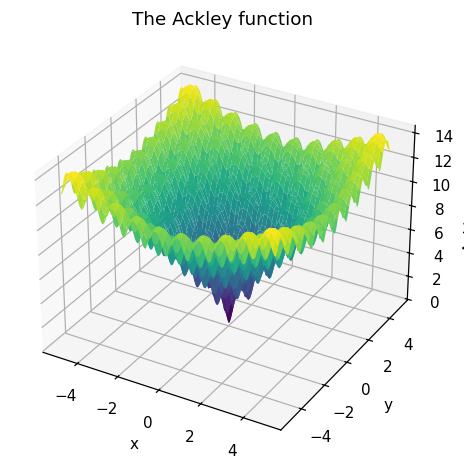

In [2]:
def ackley(s):
    x, y = s
    return (-20 * np.exp(-0.2 * np.sqrt((x ** 2 + y ** 2) / 2))
            - np.exp((np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)) / 2)
            + 20 + np.e)

xg, yg = np.meshgrid(np.linspace(-5, 5, 150), np.linspace(-5, 5, 150))
zg = ackley([xg, yg])

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(xg, yg, zg, cmap="viridis", linewidth=0, antialiased=True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Ackley(x, y)")
ax.set_title("The Ackley function")
plt.show()

## Applying Simulated Annealing

The neighbourhood function is the only piece that needs to know anything about the solution space: here, a continuous perturbation — take a small random step in $x$ and $y$.

In [3]:
def N_cont(s, step=1.0):
    """Continuous neighbourhood: a random step of at most `step` in each coordinate."""
    return (s[0] + random.uniform(-step, step), s[1] + random.uniform(-step, step))

random.seed(42)
np.random.seed(42)
s_o = (random.uniform(-5, 5), random.uniform(-5, 5))
print("Initial point:", tuple(round(v, 4) for v in s_o))
print("Initial f:", round(ackley(s_o), 5))

random.seed(42)
np.random.seed(42)
s_b, F_b = sa(s_o, ackley, N_cont, T_o=20, r=0.995, n=3000, t=1e-12)
print("\nBest point found:", tuple(round(v, 4) for v in s_b))
print("Best f found:", round(ackley(s_b), 5), " (global optimum: f(0,0) = 0)")

Initial point: (1.3943, -4.7499)
Initial f: 12.113

Best point found: (-0.0029, -0.0083)
Best f found: 0.02682  (global optimum: f(0,0) = 0)


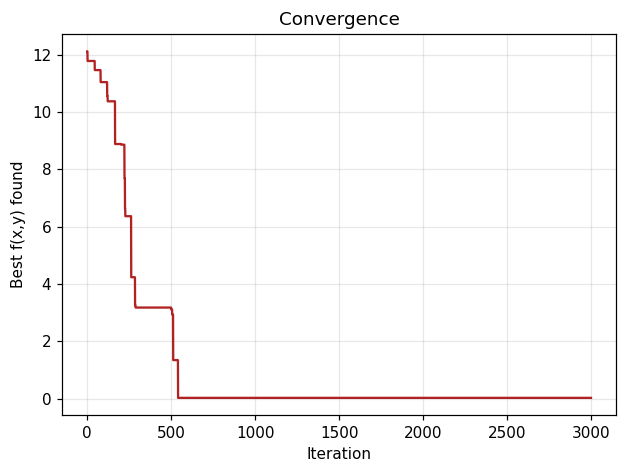

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(F_b, color="firebrick", linewidth=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Best f(x,y) found")
ax.set_title("Convergence")
ax.grid(alpha=0.3)
plt.show()

```{tip}
The convergence plot's shape is characteristic of Simulated Annealing: rapid improvement early (high temperature, large accepted moves) flattening into a long, slow tail (low temperature, only small improving moves accepted) — the same exploration-then-exploitation pattern the hand-traced example in Lecture 24 showed on a much smaller scale.
```

---

## In-Class Exercise

### Exercise 1 — Does the Step Size Matter?

Repeat the run above with a much smaller step size, keeping everything else — including the random seed — identical.

In [5]:
random.seed(42)
np.random.seed(42)
s_o_small = (random.uniform(-5, 5), random.uniform(-5, 5))  # same point, same seed
random.seed(42)
np.random.seed(42)
s_b_small, F_b_small = sa(s_o_small, ackley, lambda s: N_cont(s, step=0.2), T_o=20, r=0.995, n=3000, t=1e-12)

print("step=1.0 (main demo) best f:", round(ackley(s_b), 5))
print("step=0.2 (this exercise) best f:", round(ackley(s_b_small), 5))

step=1.0 (main demo) best f: 0.02682
step=0.2 (this exercise) best f: 7.96198


**Interpretation.** From the identical starting point and random seed, step=1.0 reaches within 0.03 of the true optimum, while step=0.2 gets stuck far away ($f\approx 7.96$). The Ackley function's surface (plotted above) is not actually smooth away from the centre — it is finely corrugated by the cosine term, creating a ring of shallow local optima. A step of 0.2 is too small to cross even one ridge of that corrugation; a step of 1.0 is large enough to jump over it. **The neighbourhood's "reach" has to be matched to the scale of the landscape's local structure** — a theme Lecture 26 studies in full.

---

## Take-Away Exercises

### Exercise 1 — A Different Starting Point

Re-run this lecture's `sa()` with `step=1.0` from three different random seeds (hence three different starting points). Does the algorithm reach a similarly good result every time? If not, how large is the gap between runs?

### Exercise 2 — A Harder Landscape

Ackley has one global minimum. Look up (or construct) a two-dimensional test function with *two* separated global minima of equal value (e.g. a symmetric double-well function), and run this lecture's `sa()` on it. Does the algorithm consistently find the same one, or does it depend on the starting point and random seed?

---

## Circling Back

- **Lecture 24 (Simulated Annealing: Motivation & Pseudocode)**: the `sa()` function above is a direct, line-by-line translation of that lecture's pseudocode — compare the `while` loop's structure and the Boltzmann acceptance line to Lines 6-13 there.

## Moving Forward

- **Lecture 26 (Simulated Annealing: Benchmarking)**: calibrates the step size and cooling schedule properly on this same Ackley function, then asks whether the calibrated settings still work when the neighbourhood changes to something built for a real routing problem.

---

## Further Reading

- Ackley, D.H. (1987). *A Connectionist Machine for Genetic Hillclimbing*. Kluwer — origin of the Ackley function as a benchmark.
- Kirkpatrick, S., Gelatt, C.D., and Vecchi, M.P. (1983). "Optimization by Simulated Annealing." *Science*, 220(4598), 671-680 — the original paper introducing SA.
- Bertsimas, D. and Tsitsiklis, J. (1993). "Simulated Annealing." *Statistical Science*, 8(1), 10-15 — a concise, rigorous treatment of cooling schedules and convergence.